In [ ]:
import sys
import os

import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("✅ Libraries loaded")

✅ Libraries loaded


In [ ]:
PROJECT_ROOT = r"D:\XO06_DS02"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: D:\XO06_DS02


In [ ]:
SCORED_PATH = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "scored_train.csv"
)

df = pd.read_csv(SCORED_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9800, 58)


,Station_ID,Timestamp,CO_Channel,NOx_Channel,NO2_Channel,Ambient_Temperature,Relative_Humidity,Absolute_Humidity,CO_Channel_RollingMean,CO_Channel_RollingStd,...,Temporal_Reliability,Statistical_Reliability,Missing_Count,Missing_Ratio,Missingness_Reliability,Relationship_Anomaly_Count,Relationship_Reliability,Trust_Score,Trust_Category,Trust_Reason
0,STN-01,01-01-2021 00:00,1.2,411.0,157.0,4.8,56.3,0.9245,NaN,NaN,...,1.0,1.0,0,0.0,1.0,0,1.0,100.0,Highly Reliable,No significant anomaly
1,STN-01,01-01-2021 01:00,1.5,397.0,167.0,2.9,54.7,0.8249,NaN,NaN,...,1.0,1.0,0,0.0,1.0,0,1.0,100.0,Highly Reliable,No significant anomaly
2,STN-01,01-01-2021 02:00,0.7,300.0,135.0,1.8,50.1,0.7405,1.133333,0.404145,...,1.0,1.0,0,0.0,1.0,0,1.0,100.0,Highly Reliable,No significant anomaly
3,STN-01,01-01-2021 03:00,0.5,284.0,142.0,0.9,48.8,0.6769,0.975000,0.457347,...,1.0,1.0,0,0.0,1.0,0,1.0,100.0,Highly Reliable,No significant anomaly
4,STN-01,01-01-2021 04:00,0.0,209.0,118.0,0.9,53.6,0.7118,0.780000,0.589067,...,1.0,1.0,0,0.0,1.0,0,1.0,100.0,Highly Reliable,No significant anomaly


In [ ]:
ML_FEATURES = [
    "CO_Channel",
    "NOx_Channel",
    "NO2_Channel",
    "Ambient_Temperature",
    "Relative_Humidity",
    "Absolute_Humidity",
    "Temporal_Anomaly_Count",
    "Statistical_Anomaly_Count",
    "Relationship_Anomaly_Count",
    "Missing_Count"
]

print("ML features:")
print(ML_FEATURES)

ML features:
['CO_Channel', 'NOx_Channel', 'NO2_Channel', 'Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity', 'Temporal_Anomaly_Count', 'Statistical_Anomaly_Count', 'Relationship_Anomaly_Count', 'Missing_Count']


In [ ]:
X = df[ML_FEATURES].copy()

# Replace infinite values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values with column median
X = X.fillna(
    X.median()
)

print("Training data shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

Training data shape: (9800, 10)
Missing values: 0


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Features scaled")

✅ Features scaled


In [ ]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

print("✅ Isolation Forest trained")

✅ Isolation Forest trained


In [ ]:
df["ML_Prediction"] = model.predict(
    X_scaled
)

df["ML_Anomaly_Score"] = (
    -model.score_samples(X_scaled)
)

print(
    df["ML_Prediction"]
    .value_counts()
)

ML_Prediction
 1    9310
-1     490
Name: count, dtype: int64


In [ ]:
df["ML_Anomaly"] = (
    df["ML_Prediction"] == -1
).astype(int)

df["ML_Status"] = np.where(
    df["ML_Anomaly"] == 1,
    "Anomalous",
    "Normal"
)

df[
    [
        "Station_ID",
        "Trust_Score",
        "Trust_Category",
        "ML_Status",
        "ML_Anomaly_Score"
    ]
].head(20)

,Station_ID,Trust_Score,Trust_Category,ML_Status,ML_Anomaly_Score
0,STN-01,100.0,Highly Reliable,Normal,0.403266
1,STN-01,100.0,Highly Reliable,Normal,0.396545
2,STN-01,100.0,Highly Reliable,Normal,0.401017
3,STN-01,100.0,Highly Reliable,Normal,0.407696
4,STN-01,100.0,Highly Reliable,Normal,0.413617
5,STN-01,100.0,Highly Reliable,Normal,0.419228
6,STN-01,100.0,Highly Reliable,Normal,0.396622
7,STN-01,100.0,Highly Reliable,Normal,0.396356
8,STN-01,100.0,Highly Reliable,Normal,0.398810
9,STN-01,100.0,Highly Reliable,Normal,0.396757


In [ ]:
df["Final_Status"] = np.where(
    (df["ML_Anomaly"] == 1) |
    (df["Trust_Score"] < 60),
    "Needs Review",
    "Trusted"
)

df[
    [
        "Trust_Score",
        "Trust_Category",
        "ML_Status",
        "Final_Status"
    ]
].head(20)

,Trust_Score,Trust_Category,ML_Status,Final_Status
0,100.0,Highly Reliable,Normal,Trusted
1,100.0,Highly Reliable,Normal,Trusted
2,100.0,Highly Reliable,Normal,Trusted
3,100.0,Highly Reliable,Normal,Trusted
4,100.0,Highly Reliable,Normal,Trusted
5,100.0,Highly Reliable,Normal,Trusted
6,100.0,Highly Reliable,Normal,Trusted
7,100.0,Highly Reliable,Normal,Trusted
8,100.0,Highly Reliable,Normal,Trusted
9,100.0,Highly Reliable,Normal,Trusted


In [ ]:
print("Final Status Distribution:")
print(
    df["Final_Status"]
    .value_counts()
)

print("\nML Anomaly Distribution:")
print(
    df["ML_Status"]
    .value_counts()
)

Final Status Distribution:
Final_Status
Trusted         9310
Needs Review     490
Name: count, dtype: int64

ML Anomaly Distribution:
ML_Status
Normal       9310
Anomalous     490
Name: count, dtype: int64


In [ ]:
ML_OUTPUT_PATH = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "ml_anomaly_results.csv"
)

df.to_csv(
    ML_OUTPUT_PATH,
    index=False
)

print("✅ ML results saved:")
print(ML_OUTPUT_PATH)

✅ ML results saved:
D:\XO06_DS02\outputs\ml_anomaly_results.csv


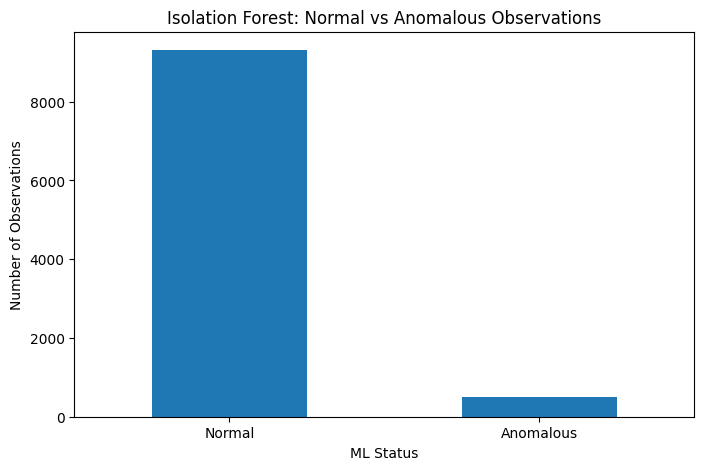

In [ ]:
import matplotlib.pyplot as plt

ml_counts = df["ML_Status"].value_counts()

plt.figure(figsize=(8, 5))

ml_counts.plot(kind="bar")

plt.xlabel("ML Status")
plt.ylabel("Number of Observations")
plt.title("Isolation Forest: Normal vs Anomalous Observations")

plt.xticks(rotation=0)
plt.show()

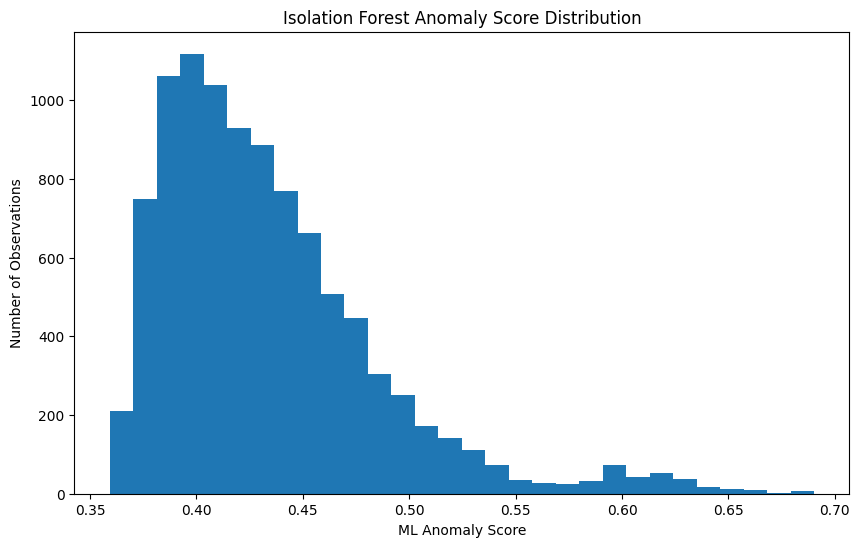

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["ML_Anomaly_Score"],
    bins=30
)

plt.xlabel("ML Anomaly Score")
plt.ylabel("Number of Observations")
plt.title("Isolation Forest Anomaly Score Distribution")

plt.show()

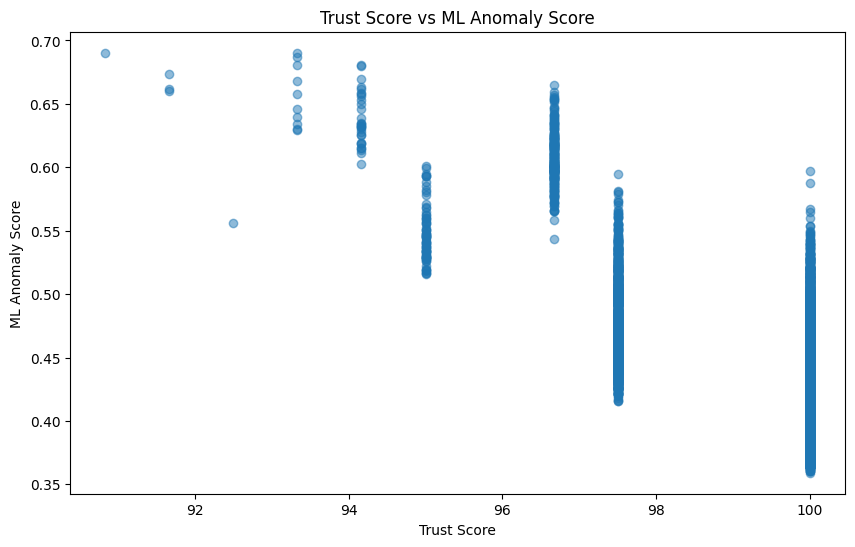

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Trust_Score"],
    df["ML_Anomaly_Score"],
    alpha=0.5
)

plt.xlabel("Trust Score")
plt.ylabel("ML Anomaly Score")
plt.title("Trust Score vs ML Anomaly Score")

plt.show()